In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree

In [4]:
# Создаём обучающую выборку
ames_data = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/AmesHousing.csv')
ames_data = ames_data[(ames_data['Lot Frontage'] <=150) & (ames_data['Lot Area'] <=20000)]
X = ames_data[['Lot Frontage', 'Lot Area']]
y = ames_data['SalePrice']

In [5]:
# Инициализируем модель дерева решений с максимальной глубиной 3 и обучаем её
dt_reg = tree.DecisionTreeRegressor(max_depth=3)
dt_reg.fit(X.values, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Отследить, как дерево решений строит свой прогноз, нам может помочь граф обученного дерева решений. Напомним, что за его визуализацию в библиотеке sklearn отвечает функция plot_tree() из модуля tree.

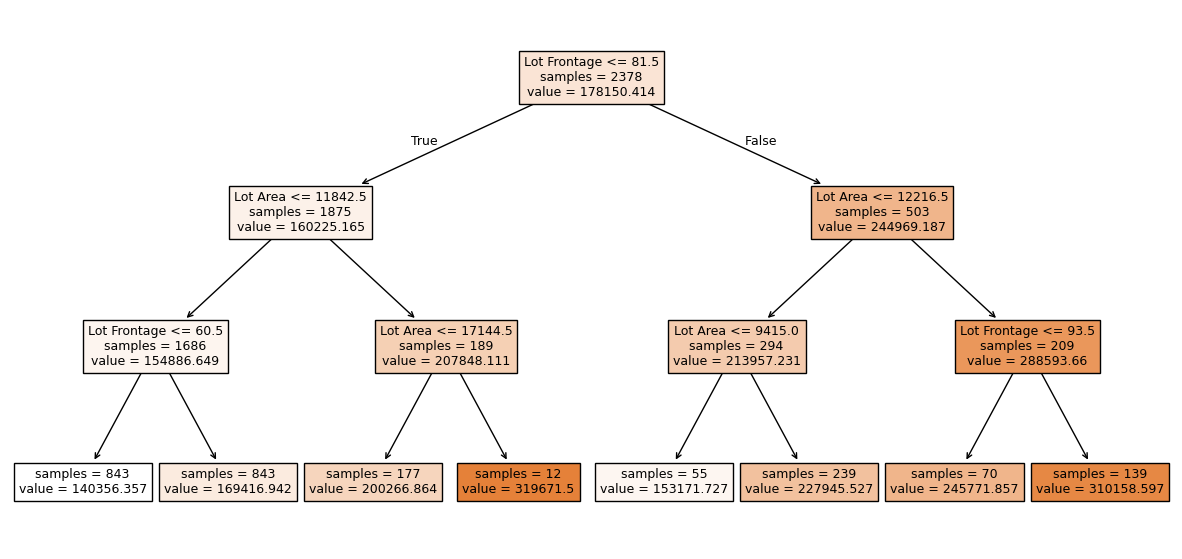

In [6]:
# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(15, 7))
tree_graph = tree.plot_tree(
    dt_reg, #дерево решений 
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=False, #отображать ли неоднородность
);

Построим диаграмму рассеяния и визуализируем то, как дерево решений разделяет пространство факторов на прямоугольные области. Для этого шага мы реализовали функцию plot_decision_bound_regression():

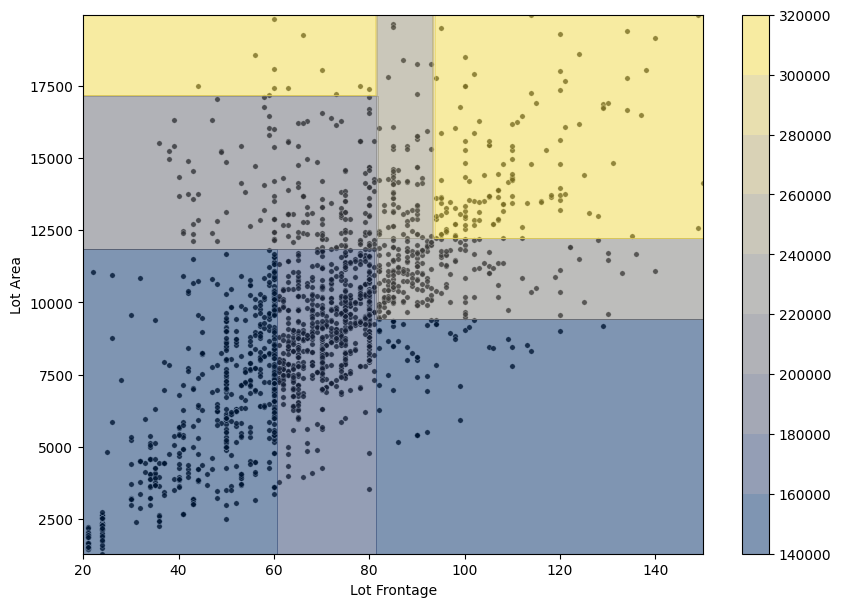

In [7]:
def plot_decision_bound_regression(X, y, model, fig):
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 1)
    )
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    y_pred = model.predict(X_net)
    y_pred = y_pred.reshape(xx1.shape)
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], s=15, color='black', alpha=0.8)
    contour = plt.contourf(xx1, xx2, y_pred, 10, cmap='cividis', alpha=0.5)
    fig.colorbar(contour)

# Визуализируем разделяющую поверхность дерева решений
fig = plt.figure(figsize = (10, 7))
plot_decision_bound_regression(X, y, dt_reg, fig)

In [16]:
bill_data

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [8]:
# Создаём обучающую выборку    
bill_data = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/bill_authentication.csv')
X = bill_data[['Variance', 'Skewness']]
y = bill_data['Class']

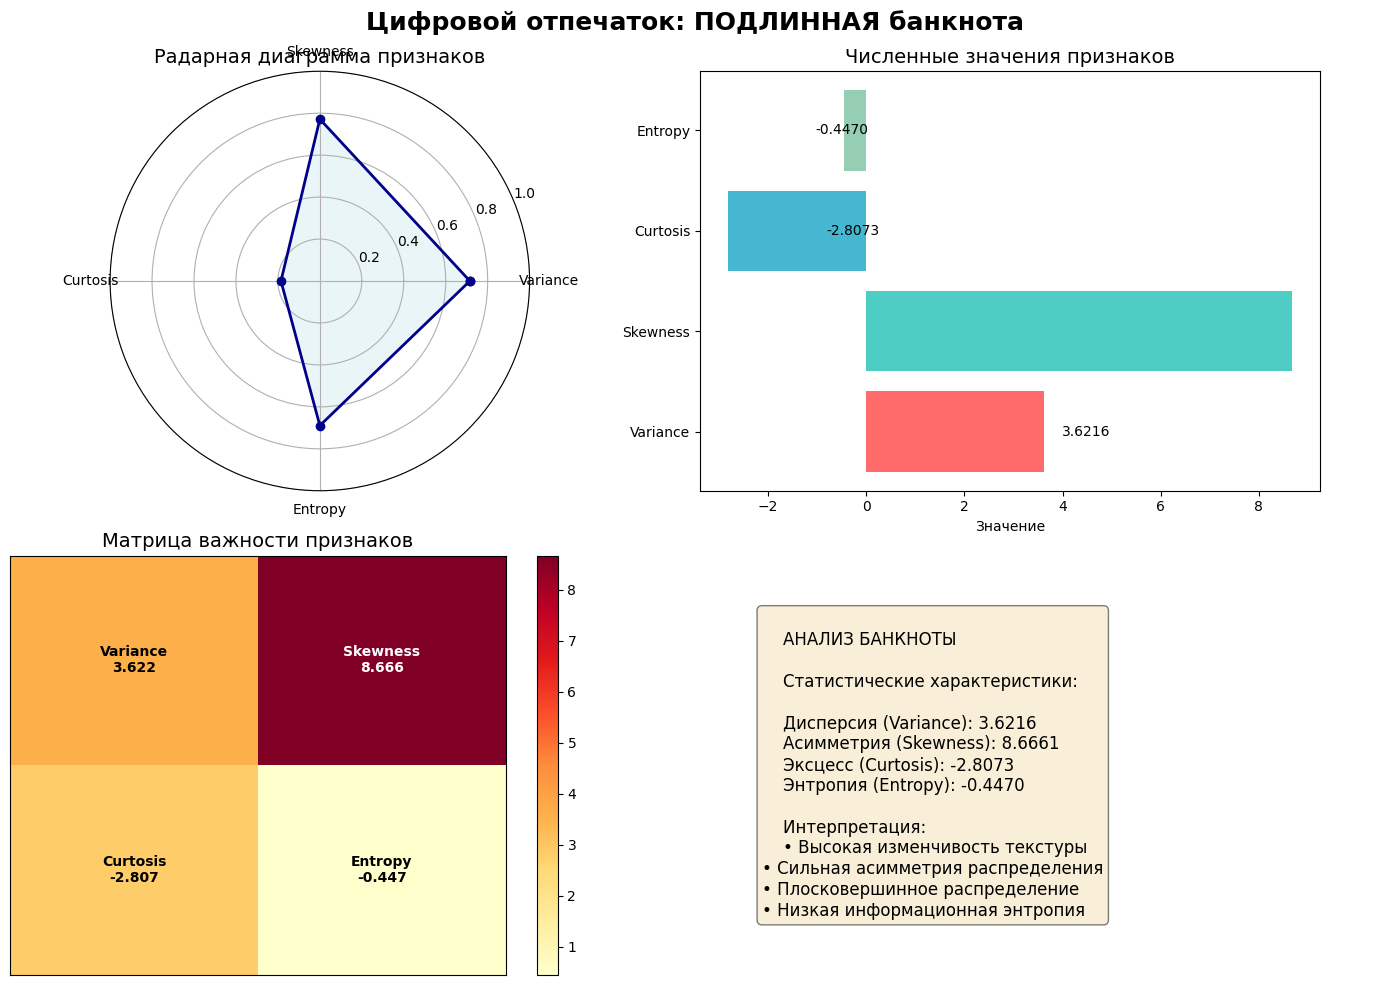

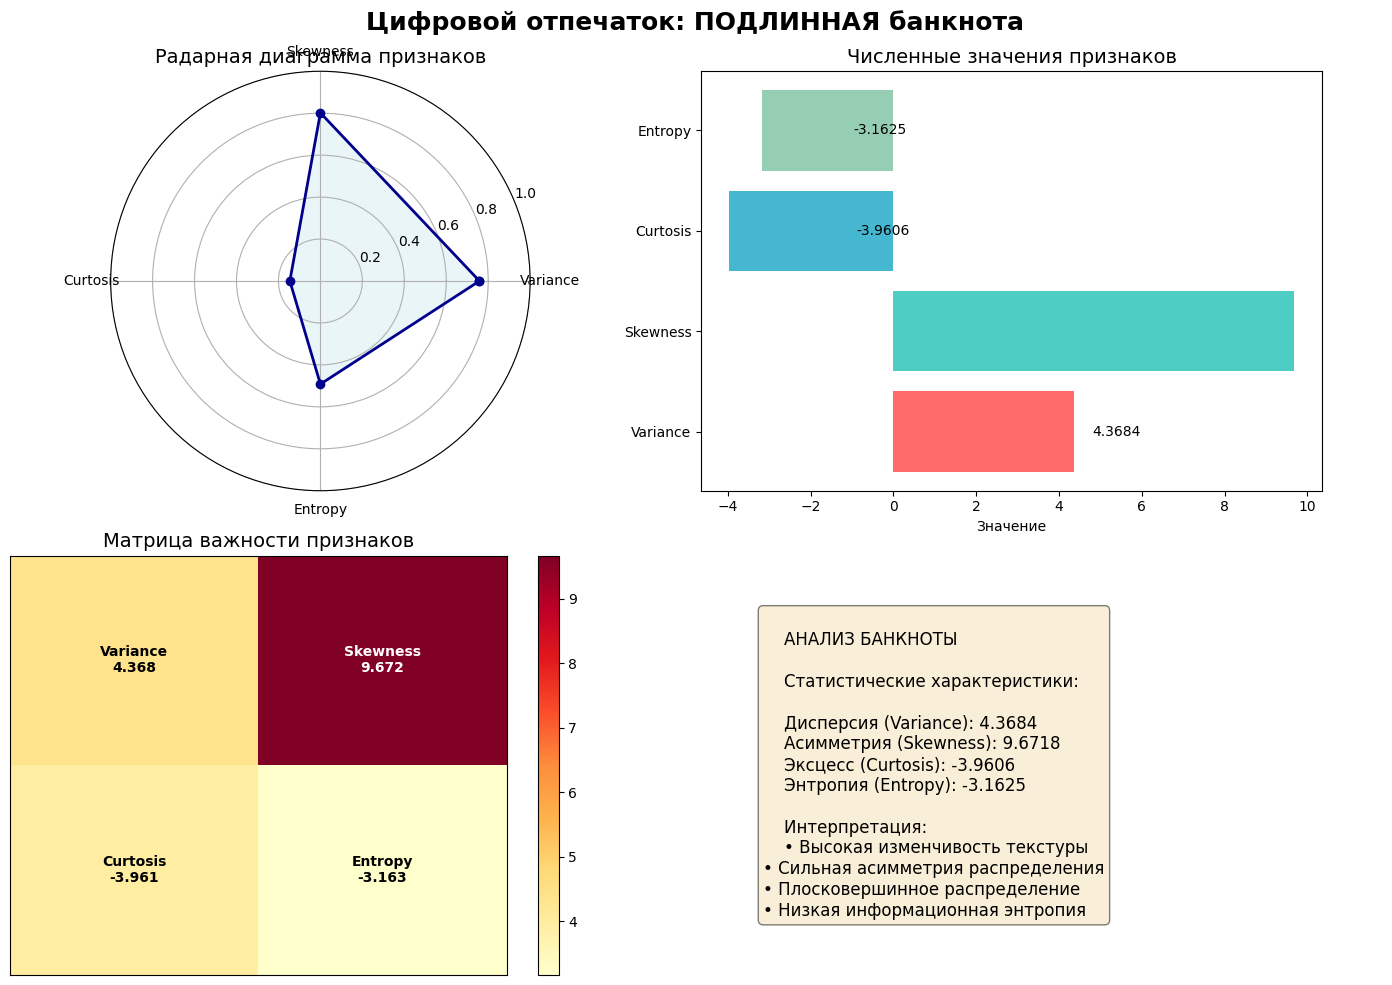

In [18]:
def create_banknote_fingerprint(features, title="Цифровой отпечаток банкноты"):
    """
    Создание визуализации "цифрового отпечатка" банкноты
    на основе 4 статистических признаков
    """
    fig = plt.figure(figsize=(14, 10))
    
    # 3.1 Радарная диаграмма
    ax1 = plt.subplot(2, 2, 1, projection='polar')
    
    categories = ['Variance', 'Skewness', 'Curtosis', 'Entropy']
    N = len(categories)
    
    # Нормализуем значения для радарной диаграммы
    values_normalized = []
    for i, (feature, value) in enumerate(zip(categories, features)):
        # Нормализация к диапазону 0-1 для визуализации
        min_val = bill_data[feature].min()
        max_val = bill_data[feature].max()
        norm_value = (value - min_val) / (max_val - min_val) * 0.8 + 0.1
        values_normalized.append(norm_value)
    
    # Углы для радарной диаграммы
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    values_normalized += values_normalized[:1]
    
    ax1.plot(angles, values_normalized, 'o-', linewidth=2, color='darkblue')
    ax1.fill(angles, values_normalized, alpha=0.25, color='lightblue')
    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(categories)
    ax1.set_ylim(0, 1)
    ax1.set_title('Радарная диаграмма признаков', fontsize=14)
    ax1.grid(True)
    
    # 3.2 Bar chart с реальными значениями
    ax2 = plt.subplot(2, 2, 2)
    y_pos = np.arange(len(categories))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    bars = ax2.barh(y_pos, features, color=colors)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(categories)
    ax2.set_xlabel('Значение')
    ax2.set_title('Численные значения признаков', fontsize=14)
    
    # Добавляем значения на bars
    for bar, value in zip(bars, features):
        ax2.text(bar.get_width() * (1.1 if value >= 0 else -0.1), 
                bar.get_y() + bar.get_height()/2,
                f'{value:.4f}', 
                va='center',
                ha='left' if value >= 0 else 'right',
                color='black' if abs(value) < max(features)*0.5 else 'white')
    
    # 3.3 Heatmap корреляции признаков (условная)
    ax3 = plt.subplot(2, 2, 3)
    
    # Создаем матрицу "важности" признаков
    importance_matrix = np.abs(features).reshape(2, 2)
    im = ax3.imshow(importance_matrix, cmap='YlOrRd', aspect='auto')
    
    # Добавляем текст
    for i in range(2):
        for j in range(2):
            idx = i * 2 + j
            ax3.text(j, i, f'{categories[idx]}\n{features[idx]:.3f}',
                    ha='center', va='center', 
                    color='white' if importance_matrix[i, j] > np.mean(importance_matrix) else 'black',
                    fontweight='bold')
    
    ax3.set_xticks([])
    ax3.set_yticks([])
    ax3.set_title('Матрица важности признаков', fontsize=14)
    plt.colorbar(im, ax=ax3)
    
    # 3.4 Текстовая информация
    ax4 = plt.subplot(2, 2, 4)
    ax4.axis('off')
    
    info_text = f"""
    АНАЛИЗ БАНКНОТЫ
    
    Статистические характеристики:
    
    Дисперсия (Variance): {features[0]:.4f}
    Асимметрия (Skewness): {features[1]:.4f}
    Эксцесс (Curtosis): {features[2]:.4f}
    Энтропия (Entropy): {features[3]:.4f}
    
    Интерпретация:
    """
    
    # Простая интерпретация
    interpretations = []
    if features[0] > 0:
        interpretations.append("• Высокая изменчивость текстуры")
    if abs(features[1]) > 2:
        interpretations.append("• Сильная асимметрия распределения")
    if features[2] > 0:
        interpretations.append("• Островершинное распределение")
    else:
        interpretations.append("• Плосковершинное распределение")
    if features[3] < 0:
        interpretations.append("• Низкая информационная энтропия")
    
    info_text += "\n".join(interpretations)
    
    ax4.text(0.1, 0.5, info_text, fontsize=12, va='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(title, fontsize=18, fontweight='bold')
    plt.tight_layout()
    return fig

# Пример для нескольких банкнот
sample_indices = [0, 5]  # Первая подлинная и первая поддельная
for idx in sample_indices:
    sample_features = bill_data.iloc[idx, :4].values
    class_label = "ПОДЛИННАЯ" if bill_data.iloc[idx, 4] == 0 else "ПОДДЕЛЬНАЯ"
    fig = create_banknote_fingerprint(sample_features, 
                                     f"Цифровой отпечаток: {class_label} банкнота")
    plt.show()

In [11]:
bill_data.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


Создадим модель дерева решений для задачи классификации (класс DecisionTreeClassifier из модуля tree библиотеки sklearn) с максимальной глубиной 4 и обучим её.

In [9]:
# Инициализируем модель дерева решений с максимальной глубиной 4 и обучаем её
dt_clf = tree.DecisionTreeClassifier(max_depth=4)
dt_clf.fit(X.values, y)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Отследить то, как дерево решений строит свой прогноз, нам может помочь граф обученного дерева решений:

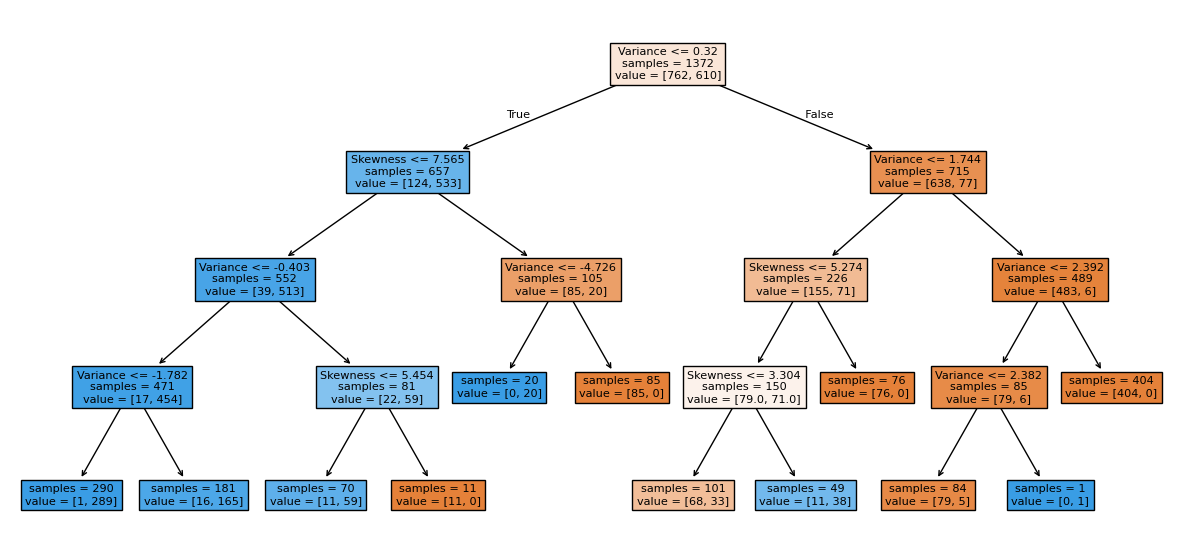

In [10]:
# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(15, 7))
tree_graph = tree.plot_tree(
    dt_clf, #дерево решений
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=False, #отображать ли неоднородность
);

Построим диаграмму рассеяния и визуализируем то, как дерево решений разделяет пространство факторов на прямоугольные области. Для этого шага мы реализовали функцию plot_decision_bound_classification():

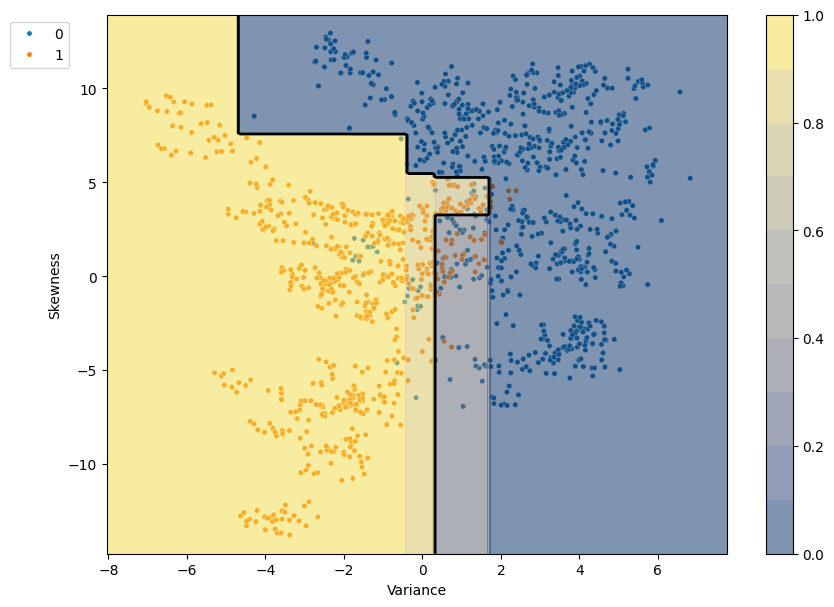

In [12]:
def plot_decision_bound_classification(X, y, model, fig):
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 0.1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 0.1)
    )
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    probs = model.predict_proba(X_net)[:, 1]
    probs = probs.reshape(xx1.shape)
    
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y, s=15, alpha=1)
    contour = plt.contourf(xx1, xx2, probs, 10, cmap='cividis', alpha=0.5)
    bound = plt.contour(xx1, xx2, probs, [0.5], linewidths=2, colors='black');
    fig.colorbar(contour)
    plt.legend(bbox_to_anchor=(-0.05, 1))
# Визуализируем разделяющую поверхность дерева решений
fig = plt.figure(figsize = (10, 7))
plot_decision_bound_classification(X, y, dt_clf, fig)

In [19]:
min_loss = inf
optimal_split_params = None
for j in range(M):
    thresholds = find_candidates_for_thresholds(X[:, j], y)
    for t in thresholds:
        split_params = (j, t)
        loss = calculate_loss(X, y, split_params)
        if loss < min_loss:
            min_loss = loss
            optimal_split_params = split_params

NameError: name 'inf' is not defined